In [6]:
import os

BASE_DATA_DIR = os.path.join(".", "data")
MODELS_DIR = os.path.join(BASE_DATA_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

from tensorflow.keras.optimizers import Adam

In [9]:
import numpy as np

X = np.load(os.path.join(BASE_DATA_DIR, 'X_mfcc_spectrogram.npy'))
y = np.load(os.path.join(BASE_DATA_DIR, 'y_labels.npy'))

print(X.shape)
print(y.shape)

(904, 40, 200, 1)
(904,)


In [10]:
# recreate label encoding
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

num_classes = len(np.unique(y_encoded))

y_categorical = to_categorical(
    y_encoded,
    num_classes=num_classes
)

In [11]:
# recreate train/validation/test split
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_categorical,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [12]:
# Verify Dataset Shapes
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (632, 40, 200, 1)
Validation: (136, 40, 200, 1)
Test: (136, 40, 200, 1)


In [13]:
# Compute Class Weights
y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(11.49090909090909), 1: np.float64(0.22815884476534296), 2: np.float64(5.056), 3: np.float64(4.861538461538461), 4: np.float64(7.9)}


In [14]:
print(label_encoder.classes_)

['Bronchiectasis' 'COPD' 'Healthy' 'Pneumonia' 'URTI']


In [15]:
model = Sequential()

# Block 1
model.add(Conv2D(32,(3,3),activation='relu',padding='same',
                 input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.30))

# Block 3
model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.30))

# Block 4
model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.40))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.50))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.40))

model.add(Dense(num_classes, activation='softmax'))

/Users/abhishekkumar/Documents/Respiratory-Audio-Classification-IT/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 200, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 200, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 100, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 100, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 100, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 100, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 25, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 25, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 25, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 25, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 12, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 12, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,146,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,670,661 (14.00 MB)

 Trainable params: 3,668,677 (13.99 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [17]:
# Compile Model
model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [19]:
#Save Best Model
checkpoint = ModelCheckpoint(
    os.path.join(MODELS_DIR, 'best_enhanced_cnn.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [20]:
# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

In [21]:
#Train Model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1789 - loss: 2.6764
Epoch 1: val_accuracy improved from None to 0.02206, saving model to ./data/models/best_enhanced_cnn.keras

Epoch 1: finished saving model to ./data/models/best_enhanced_cnn.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.1725 - loss: 2.6210 - val_accuracy: 0.0221 - val_loss: 2.2930 - learning_rate: 1.0000e-04
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1719 - loss: 2.6933
Epoch 2: val_accuracy did not improve from 0.02206
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.1867 - loss: 2.7666 - val_accuracy: 0.0221 - val_loss: 1.9648 - learning_rate: 1.0000e-04
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1778 - loss: 2.7908
Epoch 3: val_accuracy improved from 0.02206 to 0.05882, saving model to ./data/models/best_enhanced_cnn.keras

Epoch 3: finished saving model to ./data/models/best_enhanced_cnn.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - a

In [22]:
# Save model
model.save(
    os.path.join(MODELS_DIR, 'final_enhanced_cnn.keras')
)


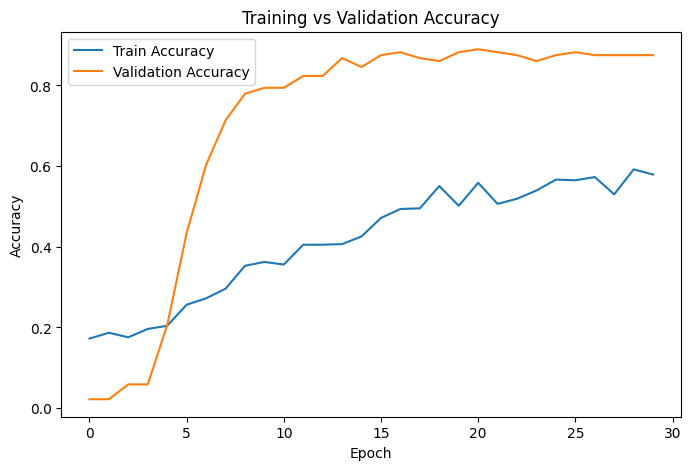

In [23]:
# Plot Accuracy
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

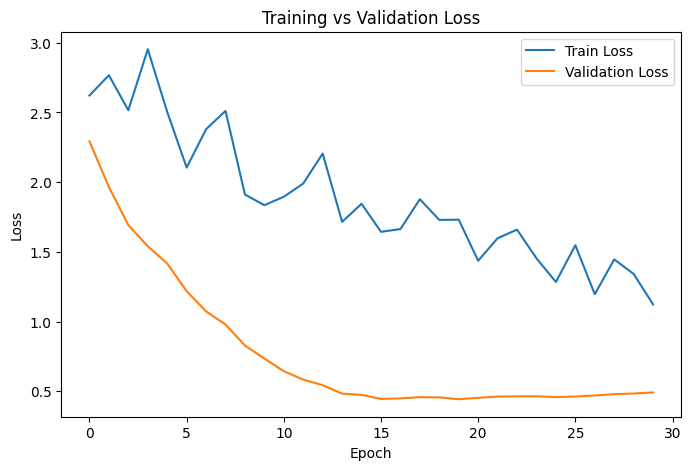

In [24]:
# Plot Loss
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [25]:
# Save Training History
import pickle

with open(
    'training_history.pkl',
    'wb'
) as f:
    pickle.dump(
        history.history,
        f
    )